In [8]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 750.2 kB/s eta 0:00:0031m? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 481.9 kB/s eta 0:00:00m eta 0:00:010:00:03
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 16.1.0
    Uninstalling pyarrow-16.1.0:
      Successfully uninstalled pyarrow-16.1.0
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [10]:
!pip uninstall pyarrow datasets -y
!pip install pyarrow==15.0.0 datasets==2.16.1


Found existing installation: pyarrow 25.0.1
Uninstalling pyarrow-25.0.1:
  Successfully uninstalled pyarrow-25.0.1
Found existing installation: datasets 5.0.1
Uninstalling datasets-5.0.1:
  Successfully uninstalled datasets-5.0.1
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.3/38.3 MB 422.3 kB/s eta 0:00:00m eta 0:00:010:00:03
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.6.1
    Uninstalling fsspec-2024.6.1:
      Successfully uninstalled fsspec-2024.6.1
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling dill-0.4.1:
      Successfully uninstalled dill-0.4.1
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.19
    Uninstalling multiprocess-0.70.19:
      Successfully uninstalled multiprocess-0.70.19
ERROR: pip's dependency resolver d

In [16]:
import pandas as pd

splits = {'train': 'train_df.csv', 'validation': 'val_df.csv', 'test': 'test_df.csv'}
df = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/" + splits["train"])
print(df.shape)
print(df.head())
print(df["sentiment"].value_counts())

(31232, 4)
      id                                               text  label sentiment
0   9536                    Cooking microwave pizzas, yummy      2  positive
1   6135  Any plans of allowing sub tasks to show up in ...      1   neutral
2  17697   I love the humor, I just reworded it. Like sa...      2  positive
3  14182                       naw idk what ur talkin about      1   neutral
4  17840          That sucks to hear. I hate days like that      0  negative
sentiment
neutral     11649
positive    10478
negative     9105
Name: count, dtype: int64


 Dataset loaded! Total rows: 41643

 Dataset shape: (41643, 4)

 Columns: ['id', 'text', 'label', 'sentiment']

 Sentiment distribution:
sentiment
neutral     15507
positive    13968
negative    12168
Name: count, dtype: int64


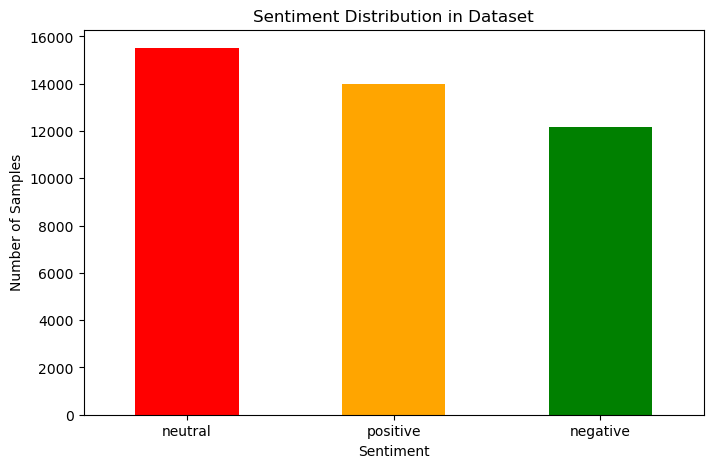

In [17]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt


train_df = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/train_df.csv")
val_df = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/val_df.csv")
test_df = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/test_df.csv")

data = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f" Dataset loaded! Total rows: {data.shape[0]}")
print(f"\n Dataset shape: {data.shape}")
print(f"\n Columns: {data.columns.tolist()}")
print(f"\n Sentiment distribution:")
print(data["sentiment"].value_counts())

plt.figure(figsize=(8, 5))
data["sentiment"].value_counts().plot(kind="bar", color=['red', 'orange', 'green'])
plt.title("Sentiment Distribution in Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()



In [23]:
#text cleaning
import re
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text=re.sub(r'@\w+','',text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
sample_texts = data["text"].head(3).tolist()
for i, text in enumerate(sample_texts):
    print(f"BEFORE {i+1}: {text}")
    print(f"AFTER  {i+1}: {clean_text(text)}")

BEFORE 1: Cooking microwave pizzas, yummy
AFTER  1: cooking microwave pizzas yummy
BEFORE 2: Any plans of allowing sub tasks to show up in the widget?
AFTER  2: any plans of allowing sub tasks to show up in the widget
BEFORE 3:  I love the humor, I just reworded it. Like saying 'group therapy' instead`a 'gang banging'. Keeps my moms off my back.   Hahaha
AFTER  3: i love the humor i just reworded it like saying group therapy insteada gang banging keeps my moms off my back hahaha


In [25]:
data["clean_text"] = data["text"].apply(clean_text)

print(f"\n Dataset shape: {data.shape}")
print(f"\n Columns: {data.columns.tolist()}")


for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"BEFORE: {data['text'].iloc[i]}")
    print(f"AFTER : {data['clean_text'].iloc[i]}")

empty_text = data[data["clean_text"] == ""].shape[0]
print(f"\n Empty cleaned texts: {empty_text}")

print(f"\n Sentiment distribution:")
print(data["sentiment"].value_counts())




 Dataset shape: (41643, 5)

 Columns: ['id', 'text', 'label', 'sentiment', 'clean_text']

Sample 1:
BEFORE: Cooking microwave pizzas, yummy
AFTER : cooking microwave pizzas yummy

Sample 2:
BEFORE: Any plans of allowing sub tasks to show up in the widget?
AFTER : any plans of allowing sub tasks to show up in the widget

Sample 3:
BEFORE:  I love the humor, I just reworded it. Like saying 'group therapy' instead`a 'gang banging'. Keeps my moms off my back.   Hahaha
AFTER : i love the humor i just reworded it like saying group therapy insteada gang banging keeps my moms off my back hahaha

 Empty cleaned texts: 55

 Sentiment distribution:
sentiment
neutral     15507
positive    13968
negative    12168
Name: count, dtype: int64


In [26]:

from sklearn.feature_extraction.text import TfidfVectorizer

X = data["clean_text"]
y = data["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Testing size: {len(X_test)}")

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\n TF-IDF complete!")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Testing features shape: {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

print(f"\n Top 10 features:")
print(tfidf.get_feature_names_out()[:10])

Training size: 33314
Testing size: 8329

 TF-IDF complete!
Training features shape: (33314, 5000)
Testing features shape: (8329, 5000)
Number of features: 5000

 Top 10 features:
['ability' 'ability to' 'able' 'able to' 'about' 'about it' 'about my'
 'about that' 'about the' 'about this']


In [27]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(
    max_iter=1000,
    random_state=42
)
model.fit(X_train_tfidf,y_train)
print(f"number of classes :{len(model.classes_)}")
print(f"classes:{model.classes_}")

number of classes :3
classes:['negative' 'neutral' 'positive']


In [28]:
y_pred=model.predict(X_test_tfidf)
print(y_pred[:10])
print(y_test[:10].values)

['neutral' 'positive' 'negative' 'neutral' 'positive' 'negative'
 'negative' 'positive' 'neutral' 'neutral']
['neutral' 'positive' 'positive' 'neutral' 'neutral' 'negative' 'neutral'
 'positive' 'neutral' 'negative']


 Accuracy: 0.6768
 Accuracy: 67.68%
              precision    recall  f1-score   support

    negative       0.69      0.64      0.67      2434
     neutral       0.60      0.66      0.63      3101
    positive       0.76      0.72      0.74      2794

    accuracy                           0.68      8329
   macro avg       0.68      0.68      0.68      8329
weighted avg       0.68      0.68      0.68      8329



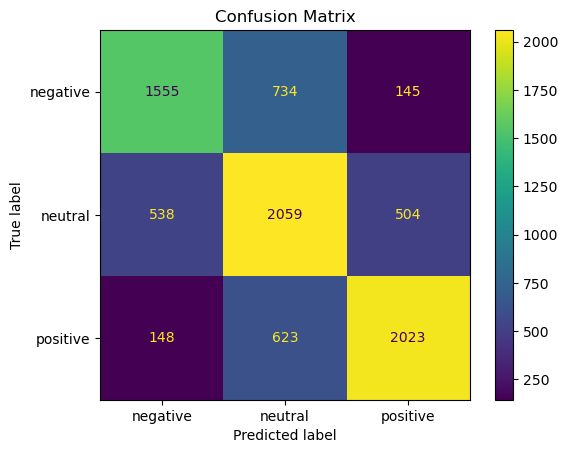

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
accuracy = accuracy_score(y_test, y_pred)
print(f" Accuracy: {accuracy:.4f}")
print(f" Accuracy: {accuracy*100:.2f}%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
display.plot()
plt.title("Confusion Matrix")
plt.show()

In [31]:
results=pd.DataFrame({
    "text":X_test.values,
    "actual":y_test.values,
    "predicted":y_pred
})
errors=results[results["actual"]!=results["predicted"]]
print(f"Total test samples: {len(results)}")
print(f"Incorrect predictions: {len(errors)}")
print(f"Error rate: {len(errors)/len(results)*100:.2f}%")
error_counts = errors.groupby(["actual", "predicted"]).size()
print(error_counts)
print(errors.head(10))


Total test samples: 8329
Incorrect predictions: 2692
Error rate: 32.32%
actual    predicted
negative  neutral      734
          positive     145
neutral   negative     538
          positive     504
positive  negative     148
          neutral      623
dtype: int64
                                                 text    actual predicted
2   good functionality and integration with gmail ...  positive  negative
4              i hope the girl at work buys my kindle   neutral  positive
6                          i had hoes now i have none   neutral  negative
9   today is a good day to dislike atampt vote out...  negative   neutral
22  however there are a few bugs every so often on...  positive   neutral
24  ugh too complicated just want plain priority l...   neutral  negative
28          i didnt get the msg but i bought princess  negative   neutral
29  wildly impressed at how much this has helped m...  positive  negative
30     you cant have your to do list as notifications  negative   n

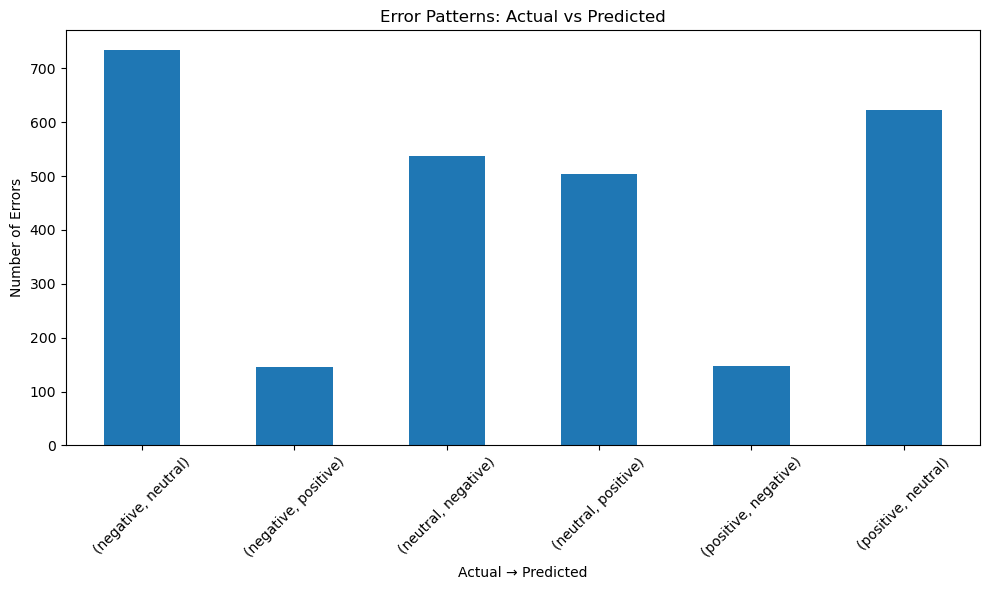

Actual: negative  Predicted: neutral  | Count:  734
Actual: positive  Predicted: neutral  | Count:  623
Actual: neutral   Predicted: negative | Count:  538
Actual: neutral   Predicted: positive | Count:  504
Actual: positive  Predicted: negative | Count:  148
Actual: negative  Predicted: positive | Count:  145


In [32]:
# Plot error patterns
plt.figure(figsize=(10, 6))
error_counts.plot(kind='bar')
plt.title('Error Patterns: Actual vs Predicted')
plt.xlabel('Actual → Predicted')
plt.ylabel('Number of Errors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
error_types = error_counts.sort_values(ascending=False)
for (actual, predicted), count in error_types.items():
    print(f"Actual: {actual:8}  Predicted: {predicted:8} | Count: {count:4}")


In [33]:
import joblib
joblib.dump(model,'sentiment_model.pkl')
joblib.dump(tfidf,'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']

In [34]:
def predict_sentiment(sentence):
    cleaned = clean_text(sentence)
    tfidf_vector = tfidf.transform([cleaned])
    prediction = model.predict(tfidf_vector)
    return prediction[0]
test_sentences = [
    "This movie was absolutely amazing!",
    "I really didn't like this product at all.",
    "It was okay, nothing special.",
    "Fantastic customer service, highly recommend!",
    "This is the worst thing I've ever bought.",
    "Pretty average, not great not terrible.",
    "I love this! Best purchase ever!",
    "The service was terrible and rude.",
    "It works fine, does the job.",
    "Absolutely brilliant! Exceeded all expectations."
]
for sentence in test_sentences:
    result = predict_sentiment(sentence)
    print(f" '{sentence}'")
    print(f"    {result}")

 'This movie was absolutely amazing!'
    positive
 'I really didn't like this product at all.'
    negative
 'It was okay, nothing special.'
    neutral
 'Fantastic customer service, highly recommend!'
    positive
 'This is the worst thing I've ever bought.'
    negative
 'Pretty average, not great not terrible.'
    negative
 'I love this! Best purchase ever!'
    positive
 'The service was terrible and rude.'
    negative
 'It works fine, does the job.'
    positive
 'Absolutely brilliant! Exceeded all expectations.'
    positive


In [36]:
print(" MULTI-CLASS SENTIMENT ANALYZER - FINAL REPORT")
print("\n DATASET INFORMATION:")
print(f"  * Total samples: {len(data)}")
print(f"  * Training samples: {len(X_train)}")
print(f"  * Testing samples: {len(X_test)}")
print(f"  * Sentiment classes: {data['sentiment'].unique().tolist()}")

print("\n CLASS DISTRIBUTION:")
for sentiment, count in data['sentiment'].value_counts().items():
    print(f"  • {sentiment}: {count} ({count/len(data)*100:.1f}%)")

print("\n MODEL PERFORMANCE:")
print(f"  * Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  * Error rate: {1-accuracy:.4f} ({(1-accuracy)*100:.2f}%)")
print(f"  * Total errors: {len(errors)} out of {len(results)}")

print("\n PER-CLASS PERFORMANCE:")
report = classification_report(y_test, y_pred, output_dict=True)
for class_name in model.classes_:
    metrics = report[class_name]
    print(f"\n  {class_name.upper()}:")
    print(f"    Precision: {metrics['precision']:.3f}")
    print(f"    Recall:    {metrics['recall']:.3f}")
    print(f"    F1-score:  {metrics['f1-score']:.3f}")

print("\n ERROR ANALYSIS:")
print("  Most common error patterns:")
error_types = errors.groupby(["actual", "predicted"]).size().sort_values(ascending=False)
for (actual, predicted), count in error_types.head(3).items():
    print(f"    {actual}  {predicted}: {count} errors")

print("\n KEY INSIGHTS:")
print("  * Neutral sentiment is the most challenging class (60% precision)")
print("  * Model performs well on strong positive/negative sentiments")
print("  * Main challenge: distinguishing neutral from slightly positive/negative")
print("  * Error rate: 32.32% - room for improvement with better models")

print("\n SAVED FILES:")
print("  * sentiment_model.pkl")
print("  * tfidf_vectorizer.pkl")



 MULTI-CLASS SENTIMENT ANALYZER - FINAL REPORT

 DATASET INFORMATION:
  * Total samples: 41643
  * Training samples: 33314
  * Testing samples: 8329
  * Sentiment classes: ['positive', 'neutral', 'negative']

 CLASS DISTRIBUTION:
  • neutral: 15507 (37.2%)
  • positive: 13968 (33.5%)
  • negative: 12168 (29.2%)

 MODEL PERFORMANCE:
  * Accuracy: 0.6768 (67.68%)
  * Error rate: 0.3232 (32.32%)
  * Total errors: 2692 out of 8329

 PER-CLASS PERFORMANCE:

  NEGATIVE:
    Precision: 0.694
    Recall:    0.639
    F1-score:  0.665

  NEUTRAL:
    Precision: 0.603
    Recall:    0.664
    F1-score:  0.632

  POSITIVE:
    Precision: 0.757
    Recall:    0.724
    F1-score:  0.740

 ERROR ANALYSIS:
  Most common error patterns:
    negative  neutral: 734 errors
    positive  neutral: 623 errors
    neutral  negative: 538 errors

 KEY INSIGHTS:
  * Neutral sentiment is the most challenging class (60% precision)
  * Model performs well on strong positive/negative sentiments
  * Main challenge: 